**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Luis Felipe García Domínguez

## Práctica 2: Procesamiento de datos
### Estadística de Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS 2025) - INEGI

En la Práctica 1 realizamos un análisis exploratorio (EDA) sobre el conjunto de datos **ATUS 2025** para conocer el comportamiento de los accidentes viales en México. Durante esa exploración encontramos varios aspectos a mejorar en los datos: registros con información faltante disfrazada de códigos numéricos (como el 0 y el 99 en la edad), un fuerte desbalance en variables clave como la presencia de alcohol, y variables temporales que pueden expresarse mejor para facilitar su análisis.

Tomando como base esos hallazgos, en esta Práctica 2 aplicamos y justificamos tres técnicas de procesamiento de datos:

1. **Limpieza de datos (Imputación):** Atender los códigos especiales en la edad del conductor (`ID_EDAD = 0` para fugas y `99` para no especificado) mediante una variable indicadora e imputación de valores, evitando descartar casi una cuarta parte del conjunto de datos como se hizo en la práctica anterior.
2. **Aumento de datos (Balanceo con SMOTE-NC):** Equilibrar la variable de aliento alcohólico (`ALIENTO`), donde los casos positivos representan una minoría frente a los negativos, generando casos sintéticos realistas para que no pasen desapercibidos en futuros análisis o modelos.
3. **Extracción de características (Ingeniería de variables de dominio):** Construir nuevas variables de mayor nivel informativo: codificación cíclica del tiempo (hora y mes) para eliminar discontinuidades matemáticas, y métricas agregadas de complejidad y severidad (`TOTAL_VEHICULOS`, `TOTAL_VICTIMAS`, `INDICE_LETALIDAD`) para compactar columnas dispersas.

---

### Contexto y procedencia del conjunto de datos

- **¿Qué mide?**  
  La siniestralidad del transporte terrestre en vialidades no federales (zonas urbanas y suburbanas) a nivel nacional, estatal y municipal. Cuantifica los incidentes viales, sus causas presuntas, los tipos de percance (colisiones, atropellamientos, volcaduras, etc.), las características de los conductores y vehículos involucrados, las condiciones de la vía y el saldo de víctimas (lesionados y personas fallecidas en el lugar del hecho, clasificadas por rol: conductor, pasajero, peatón, ciclista u otro).

- **¿Quién lo recolectó?**  
  El **Instituto Nacional de Estadística y Geografía (INEGI)**, a través de la Dirección General Adjunta de Registros Administrativos Económicos y la Dirección de Estadísticas Económicas de Registros Administrativos (DEERA).

- **¿Cuándo se recolectó?**  
  El levantamiento de incidentes se realiza de forma continua durante el año. Los datos corresponden a los percances ocurridos del **1 de enero al 31 de diciembre de 2025** (cifras anuales definitivas publicadas por el INEGI en julio de 2026).

- **¿Cuál es la unidad de observación?**  
  Cada **accidente de tránsito terrestre** ocurrido en zonas urbanas y suburbanas dentro del territorio nacional, registrado formalmente por las corporaciones de seguridad y vialidad locales.

- **Enlaces de procedencia y metadatos:**  
  - Fuente oficial: [INEGI — Accidentes de Tránsito Terrestre](https://www.inegi.org.mx/programas/accidentes/#datos_abiertos)
  - Ficha metodológica y descripción del estudio: [Catálogo Nacional de Metadatos (Estudio 1115)](https://www.inegi.org.mx/rnm/index.php/catalog/1115/study-description)
  - Diccionario de datos: [Catálogo de variables ATUS 1997-2024](https://www.inegi.org.mx/rnm/index.php/catalog/1115/data-dictionary/F1?file_name=ATUS)
  - Licencia de uso: [Términos de libre uso de información del INEGI](https://www.inegi.org.mx/inegi/terminos.html)

---

### Consideraciones sobre el diccionario de datos y subconjunto de trabajo

La base original de ATUS 2025 contiene 47 columnas (detalladas en el archivo `data/diccionario_de_datos_atus_anual_1997_2025.csv`). Al contrastar el trabajo realizado en la Práctica 1 con los requerimientos de esta Práctica 2, consideramos lo siguiente:

1. **El diccionario como guía de detección:** El catálogo oficial se usó en la Práctica 1 para identificar que códigos como `ID_EDAD = 0` y `99` no eran edades reales, sino etiquetas de omisión y fuga. En esta práctica, el diccionario sigue siendo la referencia para no tratar esas etiquetas como números y definir una técnica de imputación.

2. **El subconjunto de la Práctica 1 (26 columnas):** En la práctica anterior se seleccionaron 26 variables agrupadas en:
   - *Espacio-temporales:* `MES`, `ID_HORA`, `DIASEMANA`, `URBANA`, `SUBURBANA`, `ENTIDAD`.
   - *Circunstancias:* `TIPACCID`, `CAUSAACCI`, `CAPAROD`.
   - *Conductor:* `SEXO`, `ALIENTO`, `CINTURON`, `ID_EDAD`.
   - *Gravedad y víctimas:* 6 columnas de fallecidos, 6 de lesionados y `CLASACC`.
   En aquel momento, se descartaron a propósito las 13 columnas individuales de tipos de vehículos (`AUTOMOVIL`, `CAMPASAJ`, `MOTOCICLET`, etc.) para evitar un conjunto demasiado ancho y disperso.

3. **¿Qué conservamos y qué cambiará en la Práctica 2?**
   - **Se conserva la base conceptual:** Mantenemos las variables clave del conductor, entorno y severidad.
   - **Se reincorporan (temporalmente) los vehículos del crudo:** Rescatamos las columnas de vehículos con el fin de aplicar **extracción de características**, sumándolas en una nueva columna: `TOTAL_VEHICULOS`. Esto permitirá observar qué tan masivo fue el percance sin tener 13 columnas dispersas.
   - **Se enriquece el conjunto mediante transformaciones:** En lugar de dejar el conjunto tal como viene por defecto, lo enriquecemos con:
     - `SE_FUGO`: variable indicadora para conservar la información de los conductores que huyeron tras el choque.
     - `EDAD_IMPUTADA`: versión limpia de `ID_EDAD` sin picos artificiales en 0 y 99.
     - `HORA_SIN`, `HORA_COS`, `MES_SIN` y `MES_COS`: componentes cíclicas para una distancia temporal continua.
     - `TOTAL_VICTIMAS`: suma condensada de las 12 columnas de lesionados y muertos.
     - `INDICE_LETALIDAD`: proporción de fatalidad respecto al saldo total de víctimas.

---

### 1. Preparación del entorno y librerías

Cargamos las librerías básicas necesarias para el procesamiento, análisis y visualización de datos: **pandas**, **numpy**, **matplotlib** y **seaborn**. Más adelante incorporaremos los módulos de `scikit-learn` y `imbalanced-learn` conforme los vayamos utilizando en cada técnica.

In [138]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

print("numpy     :", np.__version__)
print("pandas    :", pd.__version__)
print("matplotlib:", __import__("matplotlib").__version__)
print("seaborn   :", sns.__version__)

numpy     : 2.5.3
pandas    : 3.0.6
matplotlib: 3.11.2
seaborn   : 0.13.2


Configuramos la paleta de colores y el estilo visual de los gráficos.

In [139]:
# Paleta de colores oficial del proyecto
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_CLARO = "#BFD5EA"
ROJO = "#C0392B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

---

### 2. Carga del conjunto de datos crudo

Para evitar duplicar 95 MB en el repositorio de GitHub, leemos el archivo principal `atus_anual_2025.csv` directamente desde `practices/practice 1/data/` mediante una ruta relativa.

Asimismo, utilizamos el catálogo oficial `tc_entidad.csv` para mapear el código numérico de entidad federativa (`CVE_ENT`) a su nombre oficial (`ENTIDAD`), facilitando la lectura de los datos.

In [140]:
# Rutas relativas a los datos (busca en practice 2, o recurre a practice 1)
RUTA_BASE_P2 = Path("../data")
RUTA_BASE_P1 = Path("../../practice 1/data")

RUTA_DATOS = (
    RUTA_BASE_P2 / "atus_anual_2025.csv"
    if (RUTA_BASE_P2 / "atus_anual_2025.csv").exists()
    else RUTA_BASE_P1 / "atus_anual_2025.csv"
)

RUTA_ENTIDADES = (
    RUTA_BASE_P2 / "tc_entidad.csv"
    if (RUTA_BASE_P2 / "tc_entidad.csv").exists()
    else RUTA_BASE_P1 / "tc_entidad.csv"
)

# Mapeo de entidades federativas
cat_entidades = pd.read_csv(RUTA_ENTIDADES)
dicc_entidades = dict(zip(cat_entidades["CVE_ENT"].astype(int), cat_entidades["NOM_ENTIDAD"]))

# Carga del conjunto crudo y asignación del nombre de entidad
crudo = pd.read_csv(RUTA_DATOS)
crudo["ENTIDAD"] = crudo["CVE_ENT"].map(dicc_entidades)

print(f"Conjunto crudo cargado: {crudo.shape[0]:,} registros × {crudo.shape[1]} atributos")

Conjunto crudo cargado: 380,391 registros × 47 atributos


### Selección del subconjunto de trabajo

De las 47 columnas originales, construimos un subconjunto enfocado que agrupa las variables en cuatro dimensiones principales:

- **Espacio-temporales:** `MES`, `ID_HORA`, `DIASEMANA`, `URBANA`, `SUBURBANA`, `ENTIDAD`.
- **Circunstancias del accidente:** `TIPACCID`, `CAUSAACCI`, `CAPAROD`.
- **Perfil del conductor:** `SEXO`, `ALIENTO`, `CINTURON`, `ID_EDAD`.
- **Vehículos involucrados (13 tipos):** Se incorporan temporalmente para sintetizarlos después en la variable agregada `TOTAL_VEHICULOS`.
- **Víctimas y gravedad:** Desglose completo de personas fallecidas y lesionadas (para derivar `TOTAL_VICTIMAS`), junto con la variable objetivo `CLASACC` (*Sólo daños*, *No fatal*, *Fatal*).

In [141]:
# 1. Variables espacio-temporales y de entorno
COLUMNAS_TEMPORALES_ESPACIALES = [
    "MES", "ID_HORA", "DIASEMANA", "URBANA", "SUBURBANA", "ENTIDAD"
]

# 2. Circunstancias del hecho
COLUMNAS_CIRCUNSTANCIAS = [
    "TIPACCID", "CAUSAACCI", "CAPAROD"
]

# 3. Datos del conductor presunto responsable
COLUMNAS_CONDUCTOR = [
    "SEXO", "ALIENTO", "CINTURON", "ID_EDAD"
]

# 4. Desglose vehicular (para extraer TOTAL_VEHICULOS)
COLUMNAS_VEHICULOS = [
    "AUTOMOVIL", "CAMPASAJ", "MICROBUS", "PASCAMION", "OMNIBUS",
    "TRANVIA", "CAMIONETA", "CAMION", "TRACTOR", "FERROCARRI",
    "MOTOCICLET", "BICICLETA", "OTROVEHIC"
]

# 5. Desglose de víctimas (para extraer TOTAL_VICTIMAS e INDICE_LETALIDAD)
COLUMNAS_MUERTOS = [
    "CONDMUERTO", "PASAMUERTO", "PEATMUERTO", "CICLMUERTO", "OTROMUERTO", "NEMUERTO"
]
COLUMNAS_HERIDOS = [
    "CONDHERIDO", "PASAHERIDO", "PEATHERIDO", "CICLHERIDO", "OTROHERIDO", "NEHERIDO"
]
COLUMNAS_VICTIMAS = COLUMNAS_MUERTOS + COLUMNAS_HERIDOS

# 6. Variable objetivo de severidad
COLUMNAS_GRAVEDAD = ["CLASACC"]

# Consolidación del subconjunto de trabajo
COLUMNAS_TRABAJO = (
    COLUMNAS_TEMPORALES_ESPACIALES +
    COLUMNAS_CIRCUNSTANCIAS +
    COLUMNAS_CONDUCTOR +
    COLUMNAS_VEHICULOS +
    COLUMNAS_VICTIMAS +
    COLUMNAS_GRAVEDAD
)

accidentes = crudo[COLUMNAS_TRABAJO].copy()

print(f"Subconjunto de trabajo preparado: {accidentes.shape[0]:,} registros × {accidentes.shape[1]} atributos")
accidentes.head(3)

Subconjunto de trabajo preparado: 380,391 registros × 39 atributos


,MES,ID_HORA,DIASEMANA,URBANA,SUBURBANA,ENTIDAD,TIPACCID,CAUSAACCI,CAPAROD,SEXO,ALIENTO,CINTURON,ID_EDAD,AUTOMOVIL,CAMPASAJ,MICROBUS,PASCAMION,OMNIBUS,TRANVIA,CAMIONETA,CAMION,TRACTOR,FERROCARRI,MOTOCICLET,BICICLETA,OTROVEHIC,CONDMUERTO,PASAMUERTO,PEATMUERTO,CICLMUERTO,OTROMUERTO,NEMUERTO,CONDHERIDO,PASAHERIDO,PEATHERIDO,CICLHERIDO,OTROHERIDO,NEHERIDO,CLASACC
0,1,3,Miércoles,Accidente en no intersección,Sin accidente en esta zona,Aguascalientes,Colisión con vehículo automotor,Conductor,Pavimentada,Hombre,Se ignora,Se ignora,29,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños
1,1,8,Miércoles,Accidente en intersección,Sin accidente en esta zona,Aguascalientes,Colisión con objeto fijo,Conductor,Pavimentada,Hombre,Sí,Se ignora,32,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños
2,1,8,Miércoles,Accidente en intersección,Sin accidente en esta zona,Aguascalientes,Colisión con objeto fijo,Conductor,Pavimentada,Mujer,Sí,Se ignora,25,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños


---

## 3. Análisis Exploratorio de Datos (EDA)

En lugar de repetir la exploración general de la Práctica 1, esta sección se enfoca directamente en diagnosticar tres situaciones en los datos que justifican las técnicas de procesamiento elegidas:

1. **Diagnóstico 1:** Faltantes encubiertos y códigos administrativos en la edad del conductor (`ID_EDAD`).
2. **Diagnóstico 2:** Desbalance marcado en la condición de aliento alcohólico (`ALIENTO`).
3. **Diagnóstico 3:** Dispersión en las columnas de vehículos y discontinuidad en la escala horaria (`ID_HORA`).

### Diagnóstico 1: Códigos especiales y faltantes encubiertos en `ID_EDAD`

Revisamos cómo se distribuye la edad del conductor para cuantificar la presencia de los códigos administrativos `0` (*Se fugó*) y `99` (*No especificado*).

Conductor se fugó (código 0)     : 34,919 (9.18 %)
Edad no especificada (código 99) : 53,152 (13.97 %)
Total códigos especiales         : 88,071 (23.15 %)
Edades válidas (12 a 98 años)    : 292,320 (76.85 %)


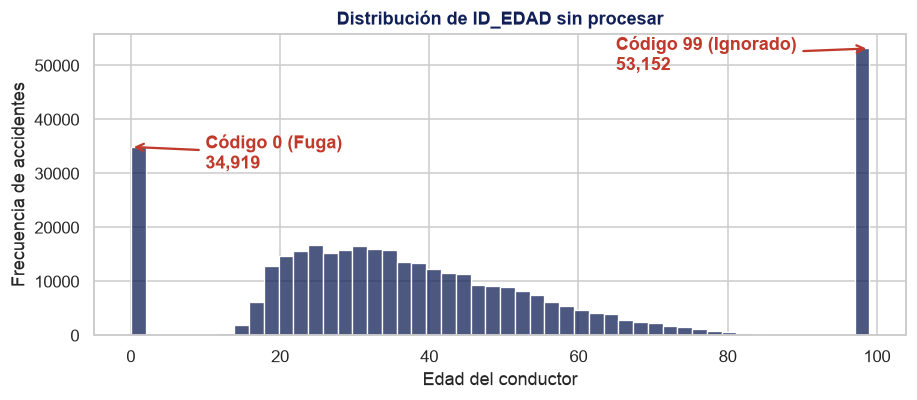

In [142]:
# Conteo de códigos especiales en ID_EDAD
conteo_fuga = (accidentes["ID_EDAD"] == 0).sum()
conteo_ignora = (accidentes["ID_EDAD"] == 99).sum()
total_registros = len(accidentes)
total_especiales = conteo_fuga + conteo_ignora

print(f"Conductor se fugó (código 0)     : {conteo_fuga:>6,} ({conteo_fuga / total_registros * 100:.2f} %)")
print(f"Edad no especificada (código 99) : {conteo_ignora:>6,} ({conteo_ignora / total_registros * 100:.2f} %)")
print(f"Total códigos especiales         : {total_especiales:>6,} ({total_especiales / total_registros * 100:.2f} %)")
print(f"Edades válidas (12 a 98 años)    : {total_registros - total_especiales:>6,} ({(total_registros - total_especiales) / total_registros * 100:.2f} %)")

# Visualización de la distribución cruda
fig, ax = plt.subplots(figsize=(8.5, 3.8))
sns.histplot(accidentes["ID_EDAD"], bins=50, color=AZUL_OSCURO, ax=ax)
ax.set_title("Distribución de ID_EDAD sin procesar")
ax.set_xlabel("Edad del conductor")
ax.set_ylabel("Frecuencia de accidentes")

# Anotaciones para señalar los códigos especiales
ax.annotate(f"Código 0 (Fuga)\n{conteo_fuga:,}", xy=(0, conteo_fuga), xytext=(10, conteo_fuga - 4000),
            arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.5), fontweight="bold", color=ROJO)
ax.annotate(f"Código 99 (Ignorado)\n{conteo_ignora:,}", xy=(99, conteo_ignora), xytext=(65, conteo_ignora - 4000),
            arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.5), fontweight="bold", color=ROJO)

plt.tight_layout()
plt.show()

**Lectura.** En la gráfica se aprecian dos picos en los extremos: el código `0` con 34,919 casos (conductores que se fugaron) y el código `99` con 53,152 casos (edad no reportada). Juntos representan el **23.15 % de los registros**.

Si dejamos estos códigos como números, sesgan cualquier análisis o modelo (la media aparente sube a 42.9 años, cuando la media real es de 37.9 años). Por otra parte, si eliminamos esas 88,071 filas, perdemos casi una cuarta parte del conjunto de datos y descartamos el perfil de quienes huyeron tras el siniestro. Esto justifica reemplazar ambos códigos por valores nulos, crear la variable indicadora `SE_FUGO` y aplicar una técnica de **imputación condicionada**.

**Nota:** En la práctica 1, si bien estos códigos no se eliminaron (en el sentido estricto de la palabra), sí se omitieron para el análisis, ya que se definieron los límites de edad mínima y máxima en 12 y 98 años, respectivamente.

---

### Diagnóstico 2: Desbalance en la condición de aliento alcohólico (`ALIENTO`)

Evaluamos la proporción de accidentes según el reporte de aliento alcohólico para diagnosticar el nivel de desbalance entre las clases.

Distribución de la variable ALIENTO:
           Registros  Porcentaje (%)
ALIENTO                             
No            229476           60.33
Se ignora     134698           35.41
Sí             16217            4.26

Proporción: 14.2 conductores con aliento negativo por cada conductor positivo.


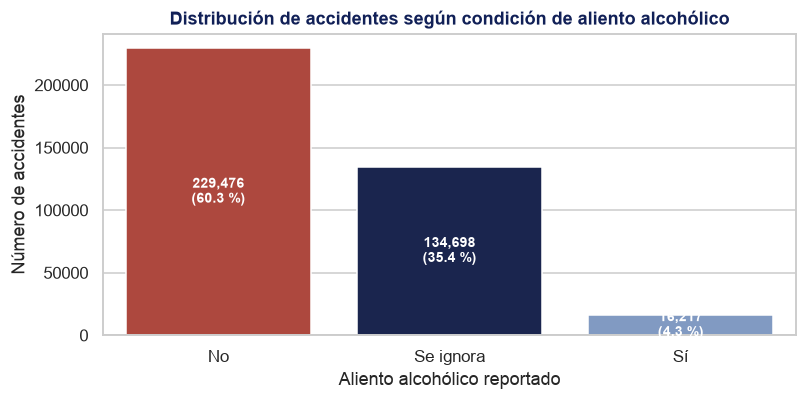

In [143]:
# Conteo de categorías de aliento alcohólico
conteo_aliento = accidentes["ALIENTO"].value_counts()
porcentajes_aliento = (accidentes["ALIENTO"].value_counts(normalize=True) * 100).round(2)

resumen_aliento = pd.DataFrame({
    "Registros": conteo_aliento,
    "Porcentaje (%)": porcentajes_aliento
})
print("Distribución de la variable ALIENTO:")
print(resumen_aliento)

# Relación entre pruebas conocidas (Sí vs No)
casos_si = conteo_aliento.get("Sí", 0)
casos_no = conteo_aliento.get("No", 0)
ratio_desbalance = casos_no / casos_si if casos_si > 0 else 0
print(f"\nProporción: {ratio_desbalance:.1f} conductores con aliento negativo por cada conductor positivo.")

# Visualización del desbalance de clases
fig, ax = plt.subplots(figsize=(7.5, 3.8))
barras = sns.countplot(
    data=accidentes,
    x="ALIENTO",
    order=["No", "Se ignora", "Sí"],
    hue="ALIENTO",
    palette=[AZUL_OSCURO, AZUL, ROJO],
    legend=False,
    ax=ax
)
ax.set_title("Distribución de accidentes según condición de aliento alcohólico")
ax.set_xlabel("Aliento alcohólico reportado")
ax.set_ylabel("Número de accidentes")

# Conteo y porcentaje sobre las barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f"{altura:,.0f}\n({altura/total_registros*100:.1f} %)",
                    (p.get_x() + p.get_width() / 2., altura / 2),
                    ha="center", va="center", color="white", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

**Lectura.** La gráfica muestra que los siniestros donde se confirmó aliento alcohólico positivo (`"Sí"`) representan apenas el **4.26 % del total** (16,217 casos), mientras que el 60.33 % es negativo y en el 35.41 % se desconoce (`"Se ignora"`).

Al comparar las dos categorías conocidas, existe una desproporción de **14 conductores sobrios por cada conductor con aliento alcohólico**. Si intentaramos entrenar un modelo con esta disparidad, tenderá a predecir siempre que el conductor no había consumido alcohol, ignorando los casos positivos y aún así obtendría un porcentaje de acierto relativamente alto. Esto justifica aplicar una técnica de **aumento de datos con SMOTE-NC** para equilibrar de manera sintética la clase menor.

---

### Diagnóstico 3: Dispersión vehicular y discontinuidad en la hora del evento

Examinamos la presencia de ceros en las 13 columnas vehiculares y la forma en que se representa linealmente la hora del accidente.

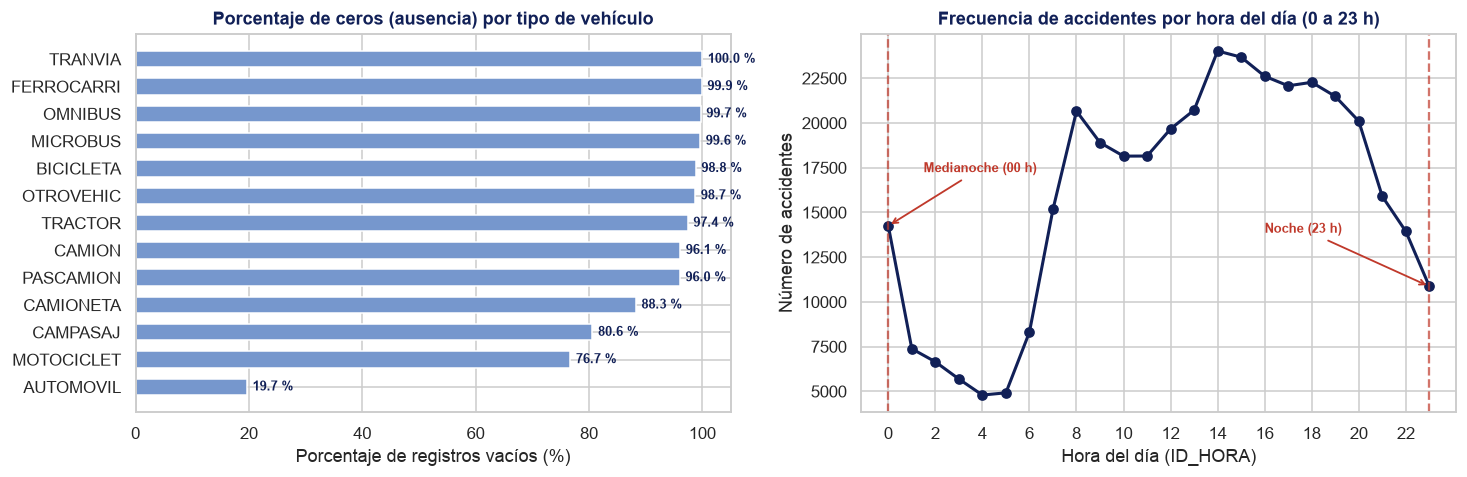

In [144]:
# 1. Porcentaje de ceros en las columnas individuales de vehículos
porcentaje_ceros = (accidentes[COLUMNAS_VEHICULOS] == 0).mean().sort_values(ascending=True) * 100

# 2. Conteo de accidentes por hora del día
conteo_por_hora = accidentes["ID_HORA"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

# Panel izquierdo: Ceros en vehículos individuales
axes[0].barh(porcentaje_ceros.index, porcentaje_ceros.values, color=AZUL, height=0.6)
axes[0].set_xlim(0, 105)
axes[0].set_title("Porcentaje de ceros (ausencia) por tipo de vehículo")
axes[0].set_xlabel("Porcentaje de registros vacíos (%)")
for i, v in enumerate(porcentaje_ceros.values):
    axes[0].text(v + 1, i, f"{v:.1f} %", va="center", fontsize=8.5, color=AZUL_OSCURO, fontweight="bold")

# Panel derecho: Escala horaria lineal tradicional
axes[1].plot(conteo_por_hora.index, conteo_por_hora.values, color=AZUL_OSCURO, marker="o", lw=2)
axes[1].set_title("Frecuencia de accidentes por hora del día (0 a 23 h)")
axes[1].set_xlabel("Hora del día (ID_HORA)")
axes[1].set_ylabel("Número de accidentes")
axes[1].set_xticks(range(0, 24, 2))

# Resaltar la separación visual entre las 23 h y las 00 h
axes[1].axvline(0, color=ROJO, ls="--", alpha=0.7)
axes[1].axvline(23, color=ROJO, ls="--", alpha=0.7)
axes[1].annotate("Medianoche (00 h)", xy=(0, conteo_por_hora[0]), xytext=(1.5, conteo_por_hora[0] + 3000),
                arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2), color=ROJO, fontweight="bold", fontsize=8.5)
axes[1].annotate("Noche (23 h)", xy=(23, conteo_por_hora[23]), xytext=(16, conteo_por_hora[23] + 3000),
                arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2), color=ROJO, fontweight="bold", fontsize=8.5)

plt.tight_layout()
plt.show()

**Lectura.** En el panel izquierdo se observa que casi todas las columnas de vehículos contienen más de un 80 % de ceros, y varias superan el 96 % (como camiones, microbuses y bicicletas). Conservar 13 columnas individuales resulta innecesario cuando lo esencial para medir la magnitud del percance es el número total de vehículos involucrados.

Por su parte, el panel derecho muestra el problema de la escala lineal: las 23:00 h y la medianoche (00:00 h) quedan en extremos opuestos de la gráfica, a pesar de que en la realidad son horas consecutivas. Ambos problemas justifican la **extracción de características**: sumando los vehículos en `TOTAL_VEHICULOS` y transformando la hora mediante funciones trigonométricas (seno y coseno) para darle continuidad circular.

---

## 4. Procesamiento 1: Limpieza de datos e imputación de edad

Como se mostró en el Diagnóstico 1, la columna `ID_EDAD` contiene 88,071 registros con códigos especiales asignados por el INEGI:
- `0`: Conductores que se dieron a la fuga tras el percance.
- `99`: Se desconoce o no se reportó la edad.

#### ¿Por qué ahora no se descartan?
En la Práctica 1 se utilizó un filtrado (`.between(12, 98)`), que respondía a los fines descriptivos y de visualización solicitados. Sin embargo, es fácil ver por qué descartar esas observaciones puede ser problemático:
1. Se desecha casi una cuarta parte del conjunto de datos, desperdiciando información de accidentes que sí ocurrieron.

2. Los conductores que se dan a la fuga (`código 0`) no son una muestra cualquiera; suelen verse involucrados en incidentes de mayor gravedad o en atropellamientos. Si son eliminados, el perfil general de los accidentes se reduce en gravedad.

#### Solución aplicada
Con base en lo visto en clase (`icd-05-limpieza.ipynb`), se plantea lo siguiente:
1. **Conservar la información de origen:** Creamos la variable `SE_FUGO = (ID_EDAD == 0).astype(int)` para registrar qué conductores huyeron del lugar.

2. **Mantener la trazabilidad:** Creamos el indicador `EDAD_ERA_FALTANTE` para reconocer qué valores fueron modificados en el preprocesamiento.
3. **Imputación por mediana:** Sustituimos los códigos `0` y `99` por valores nulos (`NaN`), y rellenamos los vacíos con la **mediana** de las edades válidas (35 años).

In [145]:
# 1. Creación de variables indicadoras de contexto y faltante
accidentes["SE_FUGO"] = (accidentes["ID_EDAD"] == 0).astype(int)
accidentes["EDAD_ERA_FALTANTE"] = accidentes["ID_EDAD"].isin([0, 99]).astype(int)

# 2. Conversión de códigos administrativos a NaN
accidentes["EDAD_LIMPIA"] = accidentes["ID_EDAD"].replace({0: np.nan, 99: np.nan})

# 3. Cálculo de la mediana sobre edades válidas
mediana_edad = accidentes["EDAD_LIMPIA"].median()

# 4. Imputación de valores ausentes con la mediana
accidentes["EDAD_IMPUTADA"] = accidentes["EDAD_LIMPIA"].fillna(mediana_edad)

# 5. Tabla comparativa de estadísticas antes y después
estadisticas_edad = pd.DataFrame({
    "Original (con 0 y 99)": accidentes["ID_EDAD"].describe(),
    "Filtrada (descarte P1)": accidentes["EDAD_LIMPIA"].describe(),
    "Imputada (P2)": accidentes["EDAD_IMPUTADA"].describe()
}).round(2)

print(f"Mediana calculada para imputación: {mediana_edad:.1f} años")
print("\nComparación estadística de la edad del conductor:")
print(estadisticas_edad)

Mediana calculada para imputación: 35.0 años

Comparación estadística de la edad del conductor:
       Original (con 0 y 99)  Filtrada (descarte P1)  Imputada (P2)
count              380391.00               292320.00      380391.00
mean                   42.93                   37.87          37.20
std                    28.18                   14.70          12.94
min                     0.00                   12.00          12.00
25%                    25.00                   26.00          29.00
50%                    37.00                   35.00          35.00
75%                    55.00                   47.00          43.00
max                    99.00                   98.00          98.00


### Comparación: Antes vs. Después de la imputación

Comparamos la distribución de la edad antes del procesamiento (con los códigos artificiales) frente a la distribución resultante tras aplicar la imputación con la mediana.

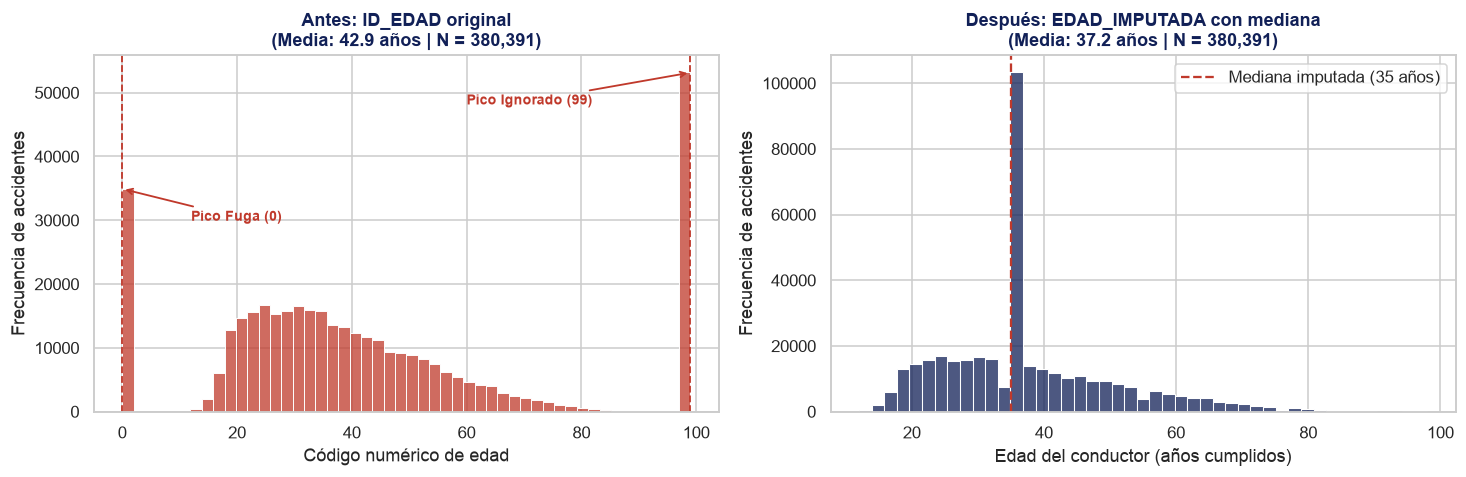

In [146]:
# Gráfica comparativa Antes vs Después
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

# Panel 1: Antes del procesamiento (códigos 0 y 99 incluidos)
sns.histplot(accidentes["ID_EDAD"], bins=50, color=ROJO, ax=axes[0])
axes[0].set_title(f"Antes: ID_EDAD original\n(Media: {accidentes['ID_EDAD'].mean():.1f} años | N = {len(accidentes):,})")
axes[0].set_xlabel("Código numérico de edad")
axes[0].set_ylabel("Frecuencia de accidentes")

# Destacar los picos artificiales
axes[0].axvline(0, color=ROJO, ls="--", lw=1.2)
axes[0].axvline(99, color=ROJO, ls="--", lw=1.2)
axes[0].annotate("Pico Fuga (0)", xy=(0, conteo_fuga), xytext=(12, conteo_fuga - 5000),
                arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2), color=ROJO, fontweight="bold", fontsize=9)
axes[0].annotate("Pico Ignorado (99)", xy=(99, conteo_ignora), xytext=(60, conteo_ignora - 5000),
                arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.2), color=ROJO, fontweight="bold", fontsize=9)

# Panel 2: Después del procesamiento (imputación con mediana)
sns.histplot(accidentes["EDAD_IMPUTADA"], bins=45, color=AZUL_OSCURO, ax=axes[1])
axes[1].set_title(f"Después: EDAD_IMPUTADA con mediana\n(Media: {accidentes['EDAD_IMPUTADA'].mean():.1f} años | N = {len(accidentes):,})")
axes[1].set_xlabel("Edad del conductor (años cumplidos)")
axes[1].set_ylabel("Frecuencia de accidentes")

# Línea vertical señalando la mediana imputada
axes[1].axvline(mediana_edad, color=ROJO, ls="--", lw=1.5, label=f"Mediana imputada ({mediana_edad:.0f} años)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

**Lectura.** En el panel izquierdo (*Antes*) se observan los picos artificiales de los códigos administrativos `0` y `99`, que además elevan la media a 42.9 años y, por supuesto, no son edades biológicamente posibles para un conductor.

En el gráfico derecho (*Después*), la imputación mediante la mediana (35 años) elimina ambos extremos y concentra los datos dentro del rango real de conducción (12 a 98 años).

Sin embargo, es evidente que ahora los datos sufren la principal limitación de la imputación simple: la masa de probabilidad se concentra en los 35 años, lo que genera un pico artificial y reduce la varianza. Este compromiso se acepta porque permite conservar el **100 % ($N = 380,391$)** de la muestra sin desechar información del resto de los atributos, además, apoyándonos en las columnas `SE_FUGO` y `EDAD_ERA_FALTANTE` permitimos que análisis posteriores identifiquen qué valores fueron estimados.

Aún así, a nivel personal surge la pregunta: `¿Se puede utilizar otra técnica de imputación que permita obtener una distribución suave?`.
Para responder a esto, utilizaremos una técnica adicional, aunque el resto del notebook se trabajará conservando los resultados obtenidos con la imputación por mediana.

### Extra: Imputación estocástica para alcanzar una distribución suave

Para responder a la pregunta planteada, implementamos la **imputación estocástica** (o por muestreo aleatorio). En lugar de asignar un valor fijo a las 88,071 observaciones ausentes, se extraen valores al azar directamente de la distribución empírica de las 292,320 edades válidas reales observadas.

Para asegurar que los resultados sean reproducibles, usamos la semilla aleatoria (`random_state=42`).

In [147]:
# 1. Generador aleatorio reproducible
rng = np.random.default_rng(42)

# 2. Extracción de edades válidas observadas (sin códigos 0 ni 99)
edades_validas = accidentes["EDAD_LIMPIA"].dropna().values

# 3. Máscara de observaciones que requieren imputación
mascara_faltantes = accidentes["EDAD_LIMPIA"].isna()
total_faltantes = mascara_faltantes.sum()

# 4. Muestreo aleatorio con reemplazo sobre las edades válidas
muestras_estocasticas = rng.choice(edades_validas, size=total_faltantes, replace=True)

# 5. Creación de la columna EDAD_ESTOCASTICA
accidentes["EDAD_ESTOCASTICA"] = accidentes["EDAD_LIMPIA"].copy()
accidentes.loc[mascara_faltantes, "EDAD_ESTOCASTICA"] = muestras_estocasticas

# 6. Tabla comparativa extendida
comparacion_completa = pd.DataFrame({
    "Original (con 0 y 99)": accidentes["ID_EDAD"].describe(),
    "Filtrada (P1)": accidentes["EDAD_LIMPIA"].describe(),
    "Mediana (P2)": accidentes["EDAD_IMPUTADA"].describe(),
    "Estocástica (Extra)": accidentes["EDAD_ESTOCASTICA"].describe()
}).round(2)

print("Comparación estadística entre métodos de tratamiento de edad:")
print(comparacion_completa)

Comparación estadística entre métodos de tratamiento de edad:
       Original (con 0 y 99)  Filtrada (P1)  Mediana (P2)  Estocástica (Extra)
count              380391.00      292320.00     380391.00            380391.00
mean                   42.93          37.87         37.20                37.87
std                    28.18          14.70         12.94                14.70
min                     0.00          12.00         12.00                12.00
25%                    25.00          26.00         29.00                26.00
50%                    37.00          35.00         35.00                35.00
75%                    55.00          47.00         43.00                47.00
max                    99.00          98.00         98.00                98.00


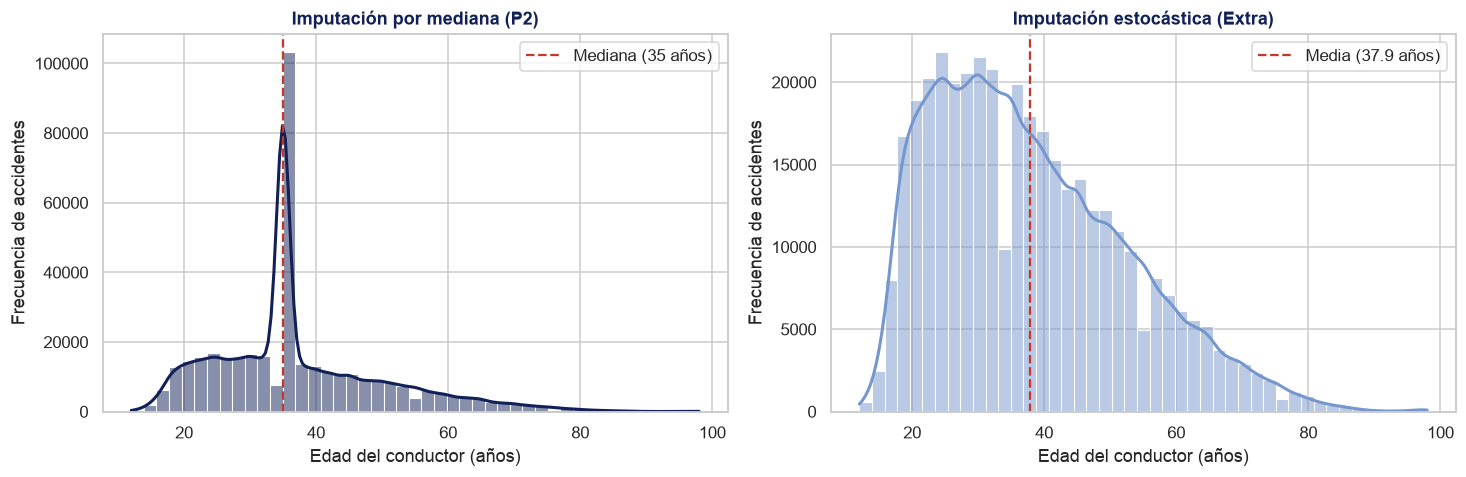

In [148]:
# Gráfica comparativa: Mediana (Pico artificial) vs Estocástica (Distribución suave)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

# Panel 1: Imputación por mediana
sns.histplot(accidentes["EDAD_IMPUTADA"], bins=45, color=AZUL_OSCURO, kde=True, ax=axes[0], line_kws={"lw": 2})
axes[0].set_title("Imputación por mediana (P2)")
axes[0].set_xlabel("Edad del conductor (años)")
axes[0].set_ylabel("Frecuencia de accidentes")
axes[0].axvline(mediana_edad, color=ROJO, ls="--", lw=1.5, label=f"Mediana ({mediana_edad:.0f} años)")
axes[0].legend(loc="upper right")

# Panel 2: Imputación estocástica
sns.histplot(accidentes["EDAD_ESTOCASTICA"], bins=45, color=AZUL, kde=True, ax=axes[1], line_kws={"lw": 2, "color": AZUL_OSCURO})
axes[1].set_title(f"Imputación estocástica (Extra)")
axes[1].set_xlabel("Edad del conductor (años)")
axes[1].set_ylabel("Frecuencia de accidentes")
axes[1].axvline(accidentes["EDAD_ESTOCASTICA"].mean(), color=ROJO, ls="--", lw=1.5,
                label=f"Media ({accidentes['EDAD_ESTOCASTICA'].mean():.1f} años)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

Verificamos la varianza.

In [149]:
print(f"Filtrada (P1):                    std = {accidentes['EDAD_LIMPIA'].std():.2f} años")
print(f"Imputación por mediana (P2):      std = {accidentes['EDAD_IMPUTADA'].std():.2f} años")
print(f"Imputación estocástica (Extra):   std = {accidentes['EDAD_ESTOCASTICA'].std():.2f} años")

Filtrada (P1):                    std = 14.70 años
Imputación por mediana (P2):      std = 12.94 años
Imputación estocástica (Extra):   std = 14.70 años


**Lectura.** La comparación visual y numérica demuestra la diferencia entre ambas técnicas:

1. Mientras que la imputación con la mediana redujo la desviación estándar a 12.94 años, la imputación estocástica mantiene la desviación estándar en **14.70 años**, igual a la muestra original filtrada de la práctica 1.

2. En el panel derecho desaparece el pico en los 35 años, se recupera una curva igual a la densidad de los conductores registrados en el país.

**Nota.** Aunque la imputación estocástica mantiene la varianza para fines descriptivos, la imputación por mediana combinada con `SE_FUGO` y `EDAD_ERA_FALTANTE` es preferible para modelos predictivos, ya que es determinista y no añade ruido. Por esta razón, y dado que el pico de valores no afecta los tipos de procesamiento que usaremos más adelante, continuaremos trabajando con EDAD_IMPUTADA.

---

## 5. Procesamiento 2: Aumento de datos (SMOTE-NC sobre `ALIENTO`)

Como se mostró en el Diagnóstico 2, la condición de aliento alcohólico (`ALIENTO`) presenta un desbalance severo en los registros con prueba confirmada:
- `No`: 229,476 casos (93.4 %)
- `Sí`: 16,217 casos (6.6 %)

Esto representa una proporción de aproximadamente **14 a 1** a favor de la clase negativa. Si se entrenara un modelo predictivo directamente con esta distribución, el algoritmo tendería a clasificar todo como `No` (alcanzando un 93.4 % de precisión), fracasando en la detección de accidentes relacionados con el consumo de alcohol.

#### Elección de SMOTE-NC
Se consideró utilizar el algoritmo SMOTE estándar, pero este genera ejemplos sintéticos interpolando linealmente vectores numéricos:

$$x_{nuevo} = x_i + \lambda (x_j - x_i)$$

En nuestro conjunto de datos (ATUS 2025), se combinan variables continuas con atributos cualitativos como `SEXO`, `URBANA` o `TIPACCID`, por lo que la interpolación con SMOTE estándar produciría valores decimales sin significado (por ejemplo, fracciones en el sexo o tipo de accidente).

Para resolver esto aplicamos **SMOTE-NC** (*Synthetic Minority Over-sampling Technique for Nominal and Continuous*), el cual:
1. Interpola linealmente las variables numéricas (`ID_HORA`, `EDAD_IMPUTADA`).
2. Determina por moda de los $k$ vecinos más cercanos la categoría asignada a cada variable cualitativa nominal (`SEXO`, `URBANA`, `TIPACCID`).

In [150]:
from imblearn.over_sampling import SMOTENC

# 1. Filtrar registros con prueba confirmada de aliento (excluyendo 'Se ignora')
accidentes_aliento = accidentes[accidentes["ALIENTO"].isin(["Sí", "No"])].copy()

# 2. Selección de características mixtas para el sobremuestreo
#    Numéricas: ID_HORA, EDAD_IMPUTADA
#    Nominales: SEXO, URBANA, TIPACCID
columnas_modelo = ["ID_HORA", "EDAD_IMPUTADA", "SEXO", "URBANA", "TIPACCID"]
X = accidentes_aliento[columnas_modelo].copy()
y = accidentes_aliento["ALIENTO"]

# 3. Índices posicionales de las columnas categóricas nominales
indices_categoricas = [2, 3, 4]  # SEXO, URBANA, TIPACCID

# 4. Aplicación de SMOTE-NC con k=5 vecinos y semilla reproducible
smote_nc = SMOTENC(categorical_features=indices_categoricas, random_state=42, k_neighbors=5)
X_res, y_res = smote_nc.fit_resample(X, y)

# 5. Construcción del conjunto balanceado con indicador de origen
n_original = len(accidentes_aliento)
n_total = len(X_res)
df_aliento_balanceado = X_res.copy()
df_aliento_balanceado["ALIENTO"] = y_res.values
df_aliento_balanceado["TIPO_MUESTRA"] = ["Original"] * n_original + ["Sintético"] * (n_total - n_original)

# 6. Tabla comparativa del balance de clases
resumen_smote = pd.DataFrame({
    "Original (Casos)": y.value_counts(),
    "Original (%)": (y.value_counts(normalize=True) * 100).round(2),
    "SMOTE-NC (Casos)": y_res.value_counts(),
    "SMOTE-NC (%)": (y_res.value_counts(normalize=True) * 100).round(2)
})

print(f"Muestras sintéticas generadas para clase 'Sí': {n_total - n_original:,}")
print("\nComparación de distribución de clases antes y después:")
print(resumen_smote)

Muestras sintéticas generadas para clase 'Sí': 213,259

Comparación de distribución de clases antes y después:
         Original (Casos)  Original (%)  SMOTE-NC (Casos)  SMOTE-NC (%)
ALIENTO                                                                
No                 229476          93.4            229476          50.0
Sí                  16217           6.6            229476          50.0


### Comparación: Antes vs. Después de SMOTE-NC

Comparamos el cambio (porcentual) en la proporción de clases (gráfico izquierdo) y visualizamos el espacio de características de la clase minoritaria (`ALIENTO = 'Sí'`), comparando las observaciones reales frente a las generadas por SMOTE-NC (panel derecho).

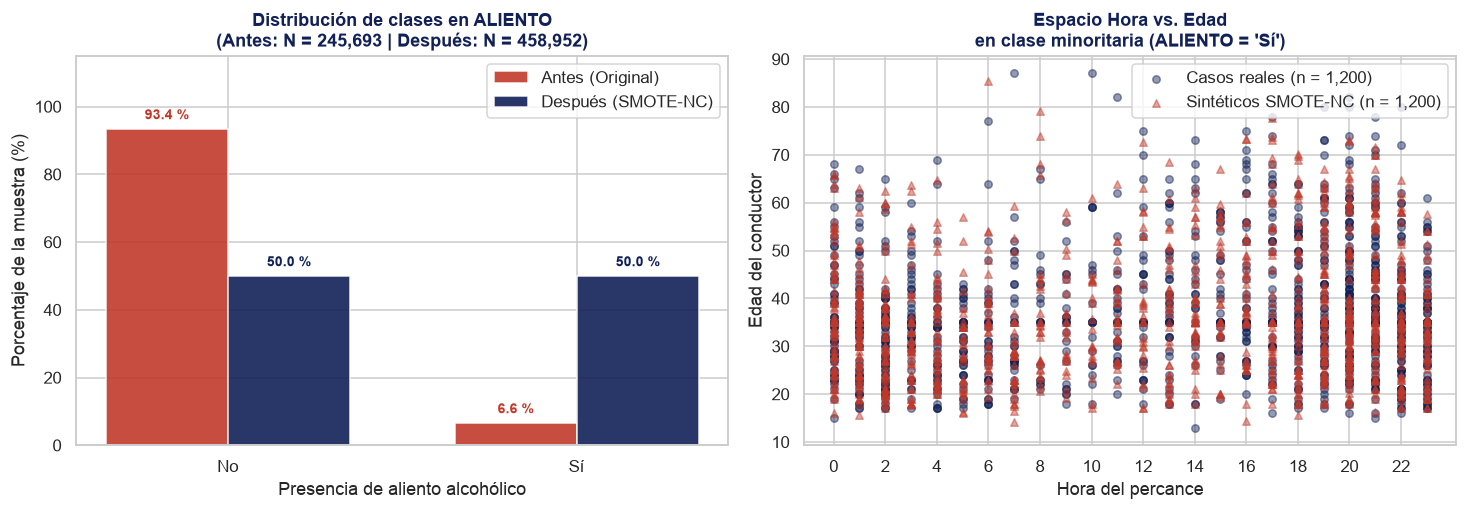

In [151]:
# Gráfica comparativa Antes vs Después de SMOTE-NC
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Panel 1: Proporción de clases en ALIENTO
categorias = ["No", "Sí"]
valores_antes = [93.4, 6.6]
valores_despues = [50.0, 50.0]
x = np.arange(len(categorias))
ancho = 0.35

rects1 = axes[0].bar(x - ancho/2, valores_antes, ancho, label="Antes (Original)", color=ROJO, alpha=0.9)
rects2 = axes[0].bar(x + ancho/2, valores_despues, ancho, label="Después (SMOTE-NC)", color=AZUL_OSCURO, alpha=0.9)

axes[0].set_title(f"Distribución de clases en ALIENTO\n(Antes: N = {n_original:,} | Después: N = {n_total:,})")
axes[0].set_xlabel("Presencia de aliento alcohólico")
axes[0].set_ylabel("Porcentaje de la muestra (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(categorias)
axes[0].set_ylim(0, 115)
axes[0].legend(loc="upper right")

# Etiquetas de porcentaje de las barras
for rect in rects1:
    h = rect.get_height()
    axes[0].annotate(f"{h:.1f} %", xy=(rect.get_x() + rect.get_width() / 2, h + 2),
                     ha="center", va="bottom", fontsize=9, fontweight="bold", color=ROJO)
for rect in rects2:
    h = rect.get_height()
    axes[0].annotate(f"{h:.1f} %", xy=(rect.get_x() + rect.get_width() / 2, h + 2),
                     ha="center", va="bottom", fontsize=9, fontweight="bold", color=AZUL_OSCURO)

# Panel 2: Espacio Hora vs. Edad
df_si = df_aliento_balanceado[df_aliento_balanceado["ALIENTO"] == "Sí"]
si_original = df_si[df_si["TIPO_MUESTRA"] == "Original"].sample(n=1200, random_state=42)
si_sintetico = df_si[df_si["TIPO_MUESTRA"] == "Sintético"].sample(n=1200, random_state=42)

axes[1].scatter(si_original["ID_HORA"], si_original["EDAD_IMPUTADA"], color=AZUL_OSCURO, alpha=0.45, s=24,
                label="Casos reales (n = 1,200)")
axes[1].scatter(si_sintetico["ID_HORA"], si_sintetico["EDAD_IMPUTADA"], color=ROJO, alpha=0.45, s=24, marker="^",
                label="Sintéticos SMOTE-NC (n = 1,200)")
axes[1].set_title("Espacio Hora vs. Edad\nen clase minoritaria (ALIENTO = 'Sí')")
axes[1].set_xlabel("Hora del percance")
axes[1].set_ylabel("Edad del conductor")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

**Lectura.** El procedimiento de aumento de datos con SMOTE-NC nos permite observar lo siguiente:

1. En el panel izquierdo (*Antes vs. Después*), la clase minoritaria de conductores con aliento alcohólico (`'Sí'`) pasó de representar un 6.6 % ($16,217$ casos) a un balance igualitario del **50.0 % ($229,476$ casos)**, lo que representa $213,259$ nuevas observaciones sintéticas.

2. En el panel derecho se confirma que los datos sintéticos (triángulos rojos) no caen en zonas sin sentido, sino que se ubican en el espacio delimitado por los conductores reales (círculos azules), concentrándose en el horario nocturno/madrugada y en edades activas de conducción.

Además, esta técnica elimina el sesgo de la clase mayoritaria en modelos de clasificación, lo que abre la posibilidad a que algoritmos futuros aprendan a distinguir conductores con aliento alcohólico sin inferir trivialmente la clase dominante.

---

## 6. Procesamiento 3: Extracción de características

Como se mostró en el Diagnóstico 3, el conjunto de datos presenta dos oportunidades para extraer nuevas variables que aporten más información mediante transformaciones:

1. En una escala lineal de 0 a 23, las 23:00 h y la medianoche (00:00 h) quedan separadas por 23 unidades de distancia numérica, a pesar de ser horas consecutivas en la realidad. Lo mismo ocurre con los meses del año (`MES`, de 1 a 12).

2. El conjunto original desglosa los vehículos en 13 columnas y las víctimas en 12 columnas, donde entre el 80 % y el 99 % de los valores son ceros, generando dimensionalidad dispersa y no completamente útil.

#### Soluciones planteadas
1. **Codificación cíclica de tiempo:** Mapeamos la hora y el mes sobre el círculo unitario trigonométrico, obteniendo sus componentes $x$ e $y$ mediante funciones seno y coseno:
$$\text{HORA}_{\text{sin}} = \sin\left(\frac{2\pi \cdot \text{ID\_HORA}}{24}\right), \quad \text{HORA}_{\text{cos}} = \cos\left(\frac{2\pi \cdot \text{ID\_HORA}}{24}\right)$$
$$\text{MES}_{\text{sin}} = \sin\left(\frac{2\pi \cdot \text{MES}}{12}\right), \quad \text{MES}_{\text{cos}} = \cos\left(\frac{2\pi \cdot \text{MES}}{12}\right)$$

2. **Suma de vehículos (`TOTAL_VEHICULOS`):** Sumamos los 13 tipos de vehículos para medir el impacto del accidente en una sola variable.

3. **Suma de víctimas y cálculo de letalidad (`TOTAL_VICTIMAS` e `INDICE_LETALIDAD`):** Sumamos los muertos y heridos en `TOTAL_VICTIMAS`, y calculamos la proporción de víctimas fatales respecto al total de afectados con:

$$\text{INDICE LETALIDAD} = \frac{\text{TOTAL MUERTOS}}{\text{TOTAL VICTIMAS}}$$

In [152]:
# 1. Codificación cíclica de variables temporales (Hora y Mes)
accidentes["HORA_SIN"] = np.sin(2 * np.pi * accidentes["ID_HORA"] / 24).round(4)
accidentes["HORA_COS"] = np.cos(2 * np.pi * accidentes["ID_HORA"] / 24).round(4)
accidentes["MES_SIN"] = np.sin(2 * np.pi * accidentes["MES"] / 12).round(4)
accidentes["MES_COS"] = np.cos(2 * np.pi * accidentes["MES"] / 12).round(4)

# 2. Agregación vehicular: condensación de 13 columnas dispersas
accidentes["TOTAL_VEHICULOS"] = accidentes[COLUMNAS_VEHICULOS].sum(axis=1)

# 3. Agregación de víctimas y severidad
accidentes["TOTAL_MUERTOS"] = accidentes[COLUMNAS_MUERTOS].sum(axis=1)
accidentes["TOTAL_HERIDOS"] = accidentes[COLUMNAS_HERIDOS].sum(axis=1)
accidentes["TOTAL_VICTIMAS"] = accidentes["TOTAL_MUERTOS"] + accidentes["TOTAL_HERIDOS"]

# 4. Índice de letalidad relativo (proporción de víctimas mortales sobre afectados)
accidentes["INDICE_LETALIDAD"] = (
    accidentes["TOTAL_MUERTOS"] / accidentes["TOTAL_VICTIMAS"].replace({0: np.nan})
).fillna(0.0).round(4)

# 5. Resumen descriptivo de las nuevas características extraídas
nuevas_columnas = [
    "HORA_SIN", "HORA_COS", "MES_SIN", "MES_COS",
    "TOTAL_VEHICULOS", "TOTAL_VICTIMAS", "INDICE_LETALIDAD"
]
print("Resumen de las variables extraídas:")
print(accidentes[nuevas_columnas].describe().round(3))

print("\nDistribución de TOTAL_VEHICULOS:")
conteo_veh = accidentes["TOTAL_VEHICULOS"].value_counts().sort_index()
tabla_veh = pd.DataFrame({
    "Vehículos involucrados": conteo_veh.index,
    "Accidentes": conteo_veh.values,
    "Porcentaje (%)": (conteo_veh.values / len(accidentes) * 100).round(2)
})
print(tabla_veh.head(5).to_string(index=False))

Resumen de las variables extraídas:
         HORA_SIN    HORA_COS     MES_SIN     MES_COS  TOTAL_VEHICULOS  TOTAL_VICTIMAS  INDICE_LETALIDAD
count  380391.000  380391.000  380391.000  380391.000       380391.000      380391.000        380391.000
mean       -0.185      -0.186      -0.000       0.003            1.896           0.241             0.010
std         0.687       0.677       0.710       0.704            0.486           0.636             0.095
min        -1.000      -1.000      -1.000      -1.000            1.000           0.000             0.000
25%        -0.866      -0.866      -0.866      -0.500            2.000           0.000             0.000
50%        -0.259      -0.259       0.000       0.000            2.000           0.000             0.000
75%         0.500       0.500       0.866       0.500            2.000           0.000             0.000
max         1.000       1.000       1.000       1.000           15.000          40.000             1.000

Distribución de TO

### Comparación 1: Antes vs. Después de la codificación cíclica del tiempo

Contrastamos la representación horaria lineal (panel izquierdo), frente a su visualización en el círculo trigonométrico (panel derecho).

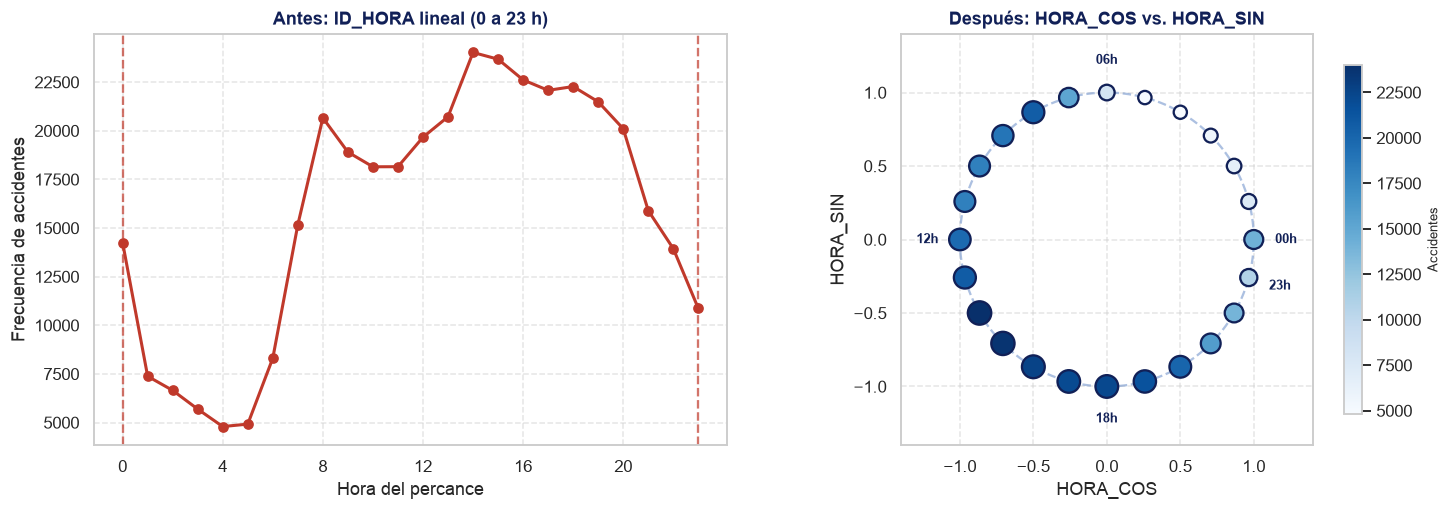

In [153]:
# Antes vs Después de la codificación cíclica de la hora
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Panel 1: Antes (HORA)
conteo_hora = accidentes["ID_HORA"].value_counts().sort_index()
axes[0].plot(conteo_hora.index, conteo_hora.values, color=ROJO, marker="o", lw=2)
axes[0].axvline(0, color=ROJO, ls="--", alpha=0.7)
axes[0].axvline(23, color=ROJO, ls="--", alpha=0.7)
axes[0].set_title("Antes: ID_HORA lineal (0 a 23 h)")
axes[0].set_xlabel("Hora del percance")
axes[0].set_ylabel("Frecuencia de accidentes")
axes[0].set_xticks(range(0, 24, 4))
axes[0].grid(True, linestyle="--", alpha=0.5)

# Panel 2: Después (HORA)
horas = np.arange(24)
th_h = 2 * np.pi * horas / 24
sin_h, cos_h = np.sin(th_h), np.cos(th_h)
frecuencias_h = conteo_hora.values
scatter_h = axes[1].scatter(cos_h, sin_h, c=frecuencias_h, cmap="Blues",
                            s=frecuencias_h/120 + 35, edgecolors=AZUL_OSCURO, lw=1.5, zorder=3)
c_th = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(c_th), np.sin(c_th), color=AZUL, ls="--", alpha=0.6, zorder=2)
for h in [0, 6, 12, 18, 23]:
    t = 2 * np.pi * h / 24
    axes[1].text(np.cos(t)*1.22, np.sin(t)*1.22, f"{h:02d}h", ha="center", va="center",
                 fontsize=8.5, fontweight="bold", color=AZUL_OSCURO)
cbar_h = plt.colorbar(scatter_h, ax=axes[1], shrink=0.85)
cbar_h.set_label("Accidentes", fontsize=8.5)
axes[1].set_title("Después: HORA_COS vs. HORA_SIN")
axes[1].set_xlabel("HORA_COS")
axes[1].set_ylabel("HORA_SIN")
axes[1].set_xlim(-1.4, 1.4)
axes[1].set_ylim(-1.4, 1.4)
axes[1].set_aspect("equal")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Lectura.** Se observa cómo, al transformar la hora (lineal) en sus componentes trigonométricos $(\sin, \cos)$, la distancia entre las 23:00 h y las 00:00 h pasa a ser (aproximadamente) $0.261$, la misma distancia que separa las 00:00 h de la 01:00 h. Así eliminamos la percepción de que existe una frontera entre ambos extremos del día. Viendo a futuro, esto podría facilitar el aprendizaje de algoritmos sensibles a distancias (como KNN, SVM o redes neuronales).

No está de más mencionar que el panel 2 se lee en sentido antihorario.

Algo similar ocurre al transformar el mes.

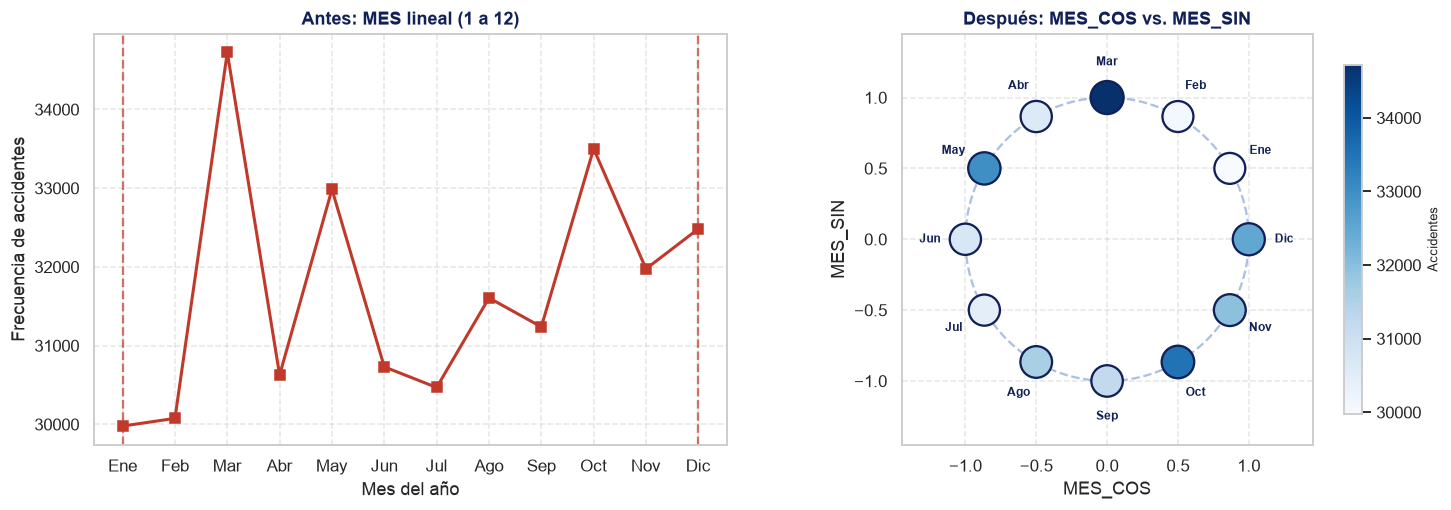

In [154]:
# Antes vs Después de la codificación cíclica del mes
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Panel 1: Antes (MES)
conteo_mes = accidentes["MES"].value_counts().sort_index()
nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
axes[0].plot(range(1, 13), conteo_mes.values, color=ROJO, marker="s", lw=2)
axes[0].axvline(1, color=ROJO, ls="--", alpha=0.7)
axes[0].axvline(12, color=ROJO, ls="--", alpha=0.7)
axes[0].set_title("Antes: MES lineal (1 a 12)")
axes[0].set_xlabel("Mes del año")
axes[0].set_ylabel("Frecuencia de accidentes")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(nombres_meses)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Panel 2: Después (MES)
meses = np.arange(1, 13)
th_m = 2 * np.pi * meses / 12
sin_m, cos_m = np.sin(th_m), np.cos(th_m)
scatter_m = axes[1].scatter(cos_m, sin_m, c=conteo_mes.values, cmap="Blues",
                            s=conteo_mes.values/80 + 35, edgecolors=AZUL_OSCURO, lw=1.5, zorder=3)
c_th = np.linspace(0, 2*np.pi, 200)
axes[1].plot(np.cos(c_th), np.sin(c_th), color=AZUL, ls="--", alpha=0.6, zorder=2)
for m, nom in zip(meses, nombres_meses):
    t = 2 * np.pi * m / 12
    axes[1].text(np.cos(t)*1.25, np.sin(t)*1.25, nom, ha="center", va="center",
                 fontsize=8, fontweight="bold", color=AZUL_OSCURO)
cbar_m = plt.colorbar(scatter_m, ax=axes[1], shrink=0.85)
cbar_m.set_label("Accidentes", fontsize=8.5)
axes[1].set_title("Después: MES_COS vs. MES_SIN")
axes[1].set_xlabel("MES_COS")
axes[1].set_ylabel("MES_SIN")
axes[1].set_xlim(-1.45, 1.45)
axes[1].set_ylim(-1.45, 1.45)
axes[1].set_aspect("equal")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

El panel 2 se lee en sentido antihorario.

### Comparación 2: Antes vs. Después de la agregación vehicular

Comparamos la dispersión en las 13 columnas vehiculares individuales (panel izquierdo), donde la gran mayoría contiene muchos ceros, frente a la suma en una sola variable (`TOTAL_VEHICULOS`, panel derecho).

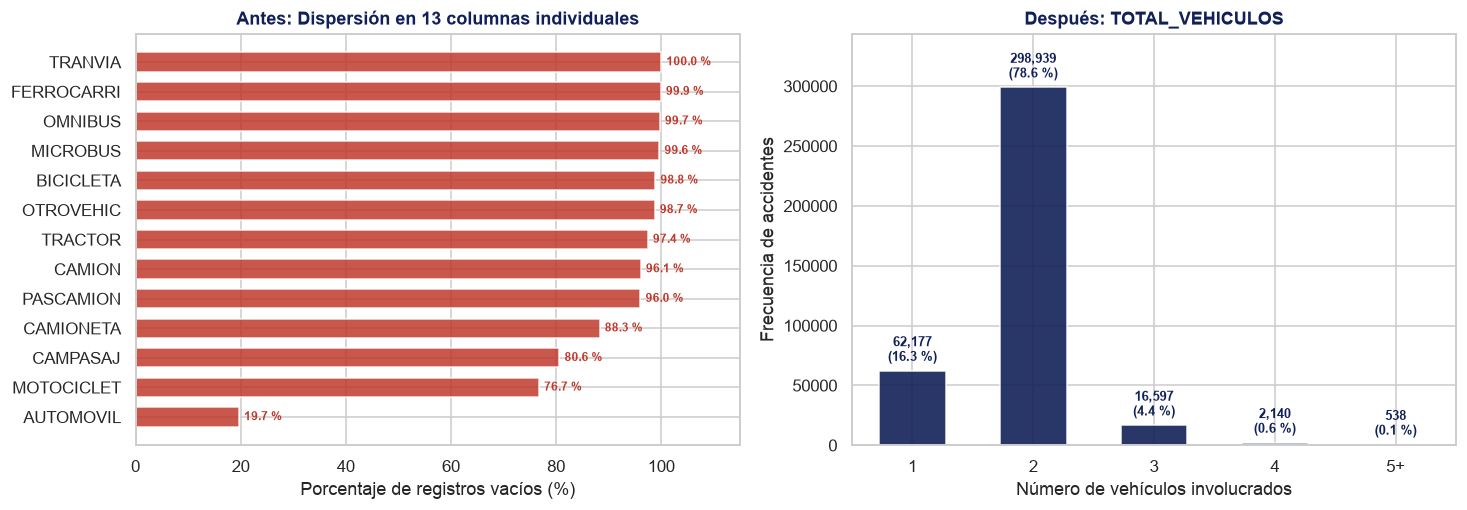

In [155]:
# Antes vs Después de la consolidación vehicular
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Panel 1: Antes
pct_ceros = (accidentes[COLUMNAS_VEHICULOS] == 0).mean().sort_values(ascending=True) * 100
bars1 = axes[0].barh(pct_ceros.index, pct_ceros.values, color=ROJO, alpha=0.85, height=0.65)
axes[0].set_title("Antes: Dispersión en 13 columnas individuales")
axes[0].set_xlabel("Porcentaje de registros vacíos (%)")
axes[0].set_xlim(0, 115)
for bar in bars1:
    w = bar.get_width()
    axes[0].annotate(f"{w:.1f} %", xy=(w + 1, bar.get_y() + bar.get_height()/2),
                     va="center", fontsize=8, color=ROJO, fontweight="bold")

# Panel 2: Después
conteo_veh = accidentes["TOTAL_VEHICULOS"].value_counts().sort_index()
veh_plot = conteo_veh.head(4).copy()
veh_plot["5+"] = conteo_veh.iloc[4:].sum()

bars2 = axes[1].bar([str(i) for i in veh_plot.index], veh_plot.values, color=AZUL_OSCURO, alpha=0.9, width=0.55)
axes[1].set_title("Después: TOTAL_VEHICULOS")
axes[1].set_xlabel("Número de vehículos involucrados")
axes[1].set_ylabel("Frecuencia de accidentes")
axes[1].set_ylim(0, max(veh_plot.values) * 1.15)
for bar in bars2:
    h = bar.get_height()
    pct = (h / len(accidentes)) * 100
    axes[1].annotate(f"{h:,}\n({pct:.1f} %)", xy=(bar.get_x() + bar.get_width()/2, h + 5000),
                     ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=AZUL_OSCURO)

plt.tight_layout()
plt.show()

**Lectura.** Es fácil observar el beneficio de la agregación de dominio. Antes se tenían 13 columnas individuales donde la gran mayoría presentaba muchos ceros. La nueva variable `TOTAL_VEHICULOS` concentra mejor la información (al ser una sola dimensión), y nos permite realizar observaciones interesantes:

- El **78.6 % ($298,939$ casos)** de los accidentes involucra a 2 vehículos (un impacto común)
- El **16.3 % ($62,177$ casos)** a 1 vehículo (un impacto con objeto o volcadura)
- El **5.1 %** restante a 3 o más vehículos (carambolas o accidentes múltiples)

### Comparación 3: Antes vs. Después de la agregación de víctimas e índice de letalidad

Contrastamos la dispersión de las 12 columnas individuales de víctimas (panel izquierdo), donde (de manera similar a lo que ocurría con los vehículos), la mayoría de celdas son ceros debido a que la mayor parte de los accidentes no registran personas heridas ni fallecidas, frente a las variables condensadas (`TOTAL_VICTIMAS` e `INDICE_LETALIDAD`, panel derecho).

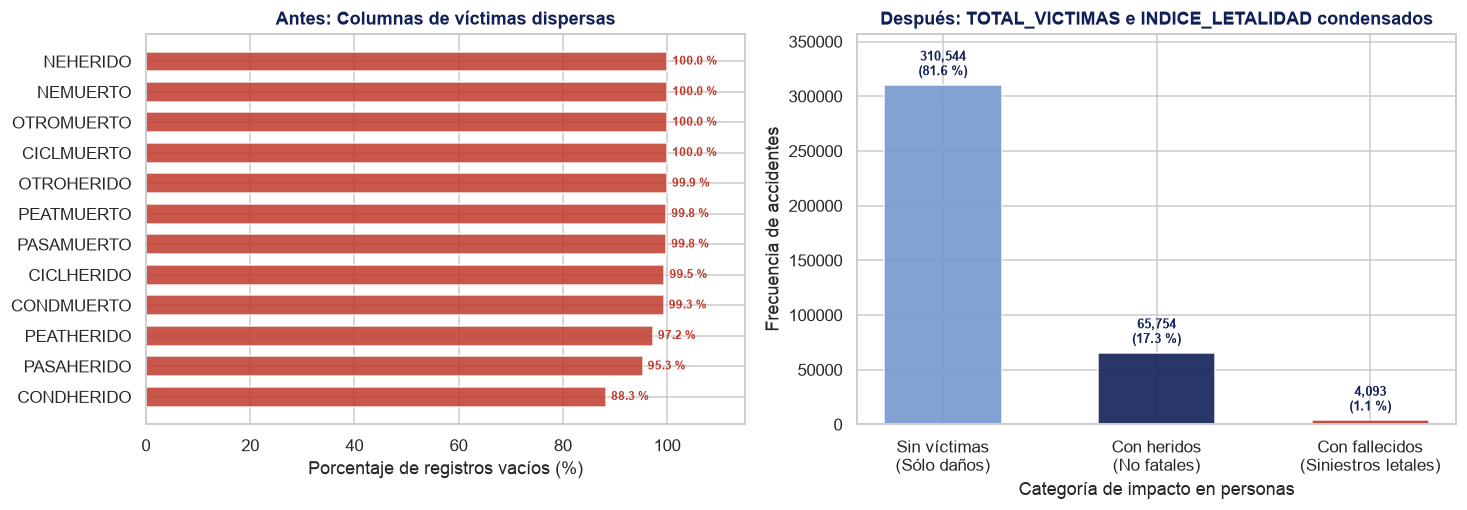

In [156]:
# Antes vs Después de la agregación de víctimas e índice de letalidad
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Panel 1: Antes
pct_ceros_vic = (accidentes[COLUMNAS_VICTIMAS] == 0).mean().sort_values(ascending=True) * 100
bars1 = axes[0].barh(pct_ceros_vic.index, pct_ceros_vic.values, color=ROJO, alpha=0.85, height=0.65)
axes[0].set_title("Antes: Columnas de víctimas dispersas")
axes[0].set_xlabel("Porcentaje de registros vacíos (%)")
axes[0].set_xlim(0, 115)
for bar in bars1:
    w = bar.get_width()
    axes[0].annotate(f"{w:.1f} %", xy=(w + 1, bar.get_y() + bar.get_height()/2),
                     va="center", fontsize=8, color=ROJO, fontweight="bold")

# Panel 2: Después
sin_vic = (accidentes["TOTAL_VICTIMAS"] == 0).sum()
no_fatal = ((accidentes["TOTAL_VICTIMAS"] > 0) & (accidentes["TOTAL_MUERTOS"] == 0)).sum()
fatal = (accidentes["TOTAL_MUERTOS"] > 0).sum()

categorias_vic = ["Sin víctimas\n(Sólo daños)", "Con heridos\n(No fatales)", "Con fallecidos\n(Siniestros letales)"]
conteos_vic = [sin_vic, no_fatal, fatal]
colores_vic = [AZUL, AZUL_OSCURO, ROJO]

bars2 = axes[1].bar(categorias_vic, conteos_vic, color=colores_vic, alpha=0.9, width=0.55)
axes[1].set_title("Después: TOTAL_VICTIMAS e INDICE_LETALIDAD condensados")
axes[1].set_xlabel("Categoría de impacto en personas")
axes[1].set_ylabel("Frecuencia de accidentes")
axes[1].set_ylim(0, max(conteos_vic) * 1.15)

for bar in bars2:
    h = bar.get_height()
    pct = (h / len(accidentes)) * 100
    axes[1].annotate(f"{h:,}\n({pct:.1f} %)", xy=(bar.get_x() + bar.get_width()/2, h + 5000),
                     ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=AZUL_OSCURO)

plt.tight_layout()
plt.show()

**Lectura.** La agregación de víctimas e índice de letalidad también nos permite simplificar el dataset:

1. En el panel izquierdo observamos que las 12 columnas originales presentan entre un 84.7 % (en `CONDHERIDO`) y más de un 99.8 % de ceros (en `PEATMUERTO`, `CICLMUERTO` y `NEMUERTO`). Conservar 12 columnas prácticamente vacías es innecesario.

2. Al sumar estas columnas en `TOTAL_VICTIMAS` y crear categorías mediante el `INDICE_LETALIDAD` (panel derecho), vemos de inmediato la distribución real de gravedad: el **81.6 % ($310,544$ accidentes)** produce únicamente daños materiales, el **17.4 % ($66,039$ accidentes)** involucra heridos no fatales, y solo el **1.0 % ($3,808$ accidentes)** termina con víctimas mortales.

---

## 7. Síntesis y Conclusiones del Preprocesamiento

En esta práctica se abordaron los principales desafíos de calidad de datos identificados en la estadística ATUS 2025 del INEGI, aplicando tres técnicas fundamentales del ciclo de ciencia de datos:

1. Limpieza de datos
2. Aumento de datos
3. Extracción de características

Verificamos las dimensiones de nuestro conjunto de datos a través del proceso:

In [157]:
# Inspección final del conjunto de datos
columnas_finales_resumen = [
    "MES_COS", "MES_SIN", "HORA_COS", "HORA_SIN",
    "EDAD_IMPUTADA", "SE_FUGO", "EDAD_ERA_FALTANTE",
    "TOTAL_VEHICULOS", "TOTAL_VICTIMAS", "INDICE_LETALIDAD",
    "SEXO", "ALIENTO", "CLASACC"
]

print("Comparación de dimensiones del conjunto de datos:")
print(f"  - Dimensiones originales (crudo INEGI)      : {crudo.shape[0]:,} filas × {crudo.shape[1]} columnas")
print(f"  - Dimensiones subconjunto de trabajo inicial: {accidentes.shape[0]:,} filas × {len(COLUMNAS_TRABAJO)} columnas")
print(f"  - Dimensiones actuales con preprocesamiento : {accidentes.shape[0]:,} filas × {accidentes.shape[1]} columnas (+{accidentes.shape[1] - len(COLUMNAS_TRABAJO)} variables de trabajo)")
print(f"  - Dimensiones balanceadas SMOTE-NC (ALIENTO): {df_aliento_balanceado.shape[0]:,} filas × {df_aliento_balanceado.shape[1]} columnas")

Comparación de dimensiones del conjunto de datos:
  - Dimensiones originales (crudo INEGI)      : 380,391 filas × 47 columnas
  - Dimensiones subconjunto de trabajo inicial: 380,391 filas × 39 columnas
  - Dimensiones actuales con preprocesamiento : 380,391 filas × 53 columnas (+14 variables de trabajo)
  - Dimensiones balanceadas SMOTE-NC (ALIENTO): 458,952 filas × 7 columnas


Observamos que, si bien el objetivo de las 14 columnas que creamos era mantener trazabilidad y compactar el dataset en categorías más informativas, al final terminamos con 53 columnas, lo que a priori parece incorrecto; sin embargo, se debe a que decidimos conservar las columnas originales para mostrar el contraste de forma adecuada entre el **Antes vs. Después**, de cada gráfico de los tipos de preprocesamiento aplicado.

Así mismo, vemos que SMOTE-NC se aplica sobre un subconjunto particular (y no sobre todo el dataset) ya que responde a una tarea específica (resolver el desbalance de la variable `ALIENTO`), al mismo tiempo que evitamos la **maldición de la dimensionalidad** en los vecinos más cercanos.

Muestra de las variables preparadas:

In [158]:
accidentes[columnas_finales_resumen].head(10)

,MES_COS,MES_SIN,HORA_COS,HORA_SIN,EDAD_IMPUTADA,SE_FUGO,EDAD_ERA_FALTANTE,TOTAL_VEHICULOS,TOTAL_VICTIMAS,INDICE_LETALIDAD,SEXO,ALIENTO,CLASACC
0,0.866,0.5,0.7071,0.7071,29.0,0,0,2,0,0.0,Hombre,Se ignora,Sólo daños
1,0.866,0.5,-0.5000,0.8660,32.0,0,0,1,0,0.0,Hombre,Sí,Sólo daños
2,0.866,0.5,-0.5000,0.8660,25.0,0,0,1,0,0.0,Mujer,Sí,Sólo daños
3,0.866,0.5,-0.7071,0.7071,35.0,1,1,1,0,0.0,Se fugó,Se ignora,Sólo daños
4,0.866,0.5,-0.9659,-0.2588,45.0,0,0,2,0,0.0,Hombre,No,Sólo daños
5,0.866,0.5,1.0000,0.0000,36.0,0,0,1,0,0.0,Hombre,Sí,Sólo daños
6,0.866,0.5,-0.5000,0.8660,31.0,0,0,2,0,0.0,Hombre,No,Sólo daños
7,0.866,0.5,-0.8660,0.5000,52.0,0,0,1,0,0.0,Mujer,No,Sólo daños
8,0.866,0.5,0.2588,0.9659,33.0,0,0,1,0,0.0,Hombre,No,Sólo daños
9,0.866,0.5,-1.0000,0.0000,72.0,0,0,2,0,0.0,Hombre,No,Sólo daños


### Conclusiones

1. A diferencia de la Práctica 1 (donde el filtrado descriptivo desechó cerca de una cuarta parte de la base), la estrategia de limpieza utilizada en esta práctica demuestra que es posible mantener la integridad del dataset ($100 \%$ de los casos) al crear indicadores (`SE_FUGO`, `EDAD_ERA_FALTANTE`) que nos aporten transparencia sobre lo que se hizo.

2. El aumento de datos mediante **SMOTE-NC** demostró ser la alternativa correcta para conjuntos mixtos. Se generaron $213,259$ observaciones sintéticas sin alterar la validez de las categorías cualitativas (`SEXO`, `URBANA`, `TIPACCID`). Se eliminó el riesgo de que un modelo predictivo alcance un $93.4 \%$ de exactitud solo con ignorar a los conductores con aliento alcohólico.

3. La transformación cíclica de la hora y el mes corrigió la ruptura que se percibe con el manejo lineal del tiempo (para la media noche y el año nuevo). Asimismo, la consolidación de 13 tipos de vehículos en `TOTAL_VEHICULOS` y de 12 categorías de afectados en `TOTAL_VICTIMAS` e `INDICE_LETALIDAD` permitió compactar el dataset, lo que podría facilitar el entrenamiento de modelos de severidad vial (`CLASACC`).

---

### Declaración sobre el uso de IA Generativa

Este notebook fue elaborado con apoyo de modelos de lenguaje basados en IA (Antigravity / Gemini) como asistentes para la estructuración, depuración de código y la revisión de redacción. El razonamiento analítico, la selección y justificación de las técnicas de preprocesamiento, la interpretación de resultados y la validación de la integridad metodológica son responsabilidad del autor.

---

### Referencias

1. **INEGI (2026).** *Estadística de Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS 2025), cifras definitivas*. Instituto Nacional de Estadística y Geografía. [https://www.inegi.org.mx/programas/accidentes/](https://www.inegi.org.mx/programas/accidentes/)
2. **Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002).** *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research (JAIR), 16, 321–357.
3. **López Nava, I. H. (2026).** *Materiales de clase: Introducción a la Ciencia de Datos (icd-05-limpieza, icd-06-aumento, icd-07-ingenieria)*. Posgrado en Ciencias de la Computación, CICESE.